# CARRA1 vs FCN3 / GraphCast / HRES

Uses the Copernicus Arctic Regional Reanalysis (CARRA1, 2.5 km, HARMONIE-AROME, CARRA-East
domain) as an independent, higher-resolution reference alongside the existing station-Obs and
ERA5 comparisons in `model_comparison_analysis_72h_interpolate.ipynb`.

**Why CARRA and not just ERA5**: all 12 stations sit in fjord/island/coastal terrain that ERA5's
31 km grid cannot resolve. Køltzow et al. (2022, Polar Research) evaluate CARRA specifically over
"Svalbard, northern Norway, Sweden and Finland" and find real but *more modest* added value for
wind speed than for temperature — that calibrates what to expect here.

**What this notebook does**: FCN3/GraphCast/HRES are scored against CARRA1 the same way they are
already scored against ERA5 elsewhere (`compute_group_metrics(df, 'forecast', 'carra', ...)`),
not against station Obs. CARRA does not assimilate near-surface wind observations (only surface
pressure, 2 m temperature/humidity, and snow depth), so scoring a forecast against CARRA is not
the same kind of "target already seen the answer" issue that would apply to a directly-assimilated
variable — but pressure assimilation still constrains the flow indirectly (via the pressure-gradient
/ geostrophic relationship), worth keeping in mind when interpreting results.

A CARRA-vs-Obs comparison (as done for ERA5-vs-Obs elsewhere) is more straightforward: since CARRA's
wind field is not directly nudged by station wind observations, it is a genuinely independent estimate
at each station, so `compute_group_metrics(df, 'obs', 'carra', ...)` is a clean check of CARRA's own
accuracy rather than a circular one — the only caveat is the same indirect pressure-assimilation
coupling noted above.

**Caveat inherited from `area` not being supported**: the CARRA-East grid uses a native rotated
Lambert Conformal projection; the CDS/MARS backend cannot crop it server-side
(`Representation::croppedRepresentation() not implemented for RegularGrid[...projection=lcc...]`).
Every download therefore returns the full ~989x789-point domain (~2-3 GB/year as netCDF), and we
discard all but the 12 station grid cells immediately after each download.

In [1]:
import sys
sys.path.insert(0, '/cluster/work/projects/nn8106k/siyan/pip_cache')

import warnings
warnings.filterwarnings('ignore')

import cdsapi
from pyproj import CRS, Transformer
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Paths
OUT_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study')
CSV_MASTER = OUT_ROOT / 'master_forecast_dataset_72h_interp.csv'
FIG_DIR    = OUT_ROOT / 'figures_carra'
FIG_DIR.mkdir(parents=True, exist_ok=True)

CARRA_RAW_DIR      = Path('/cluster/work/projects/nn8106k/siyan/CARRA/raw')
CARRA_RAW_DIR.mkdir(parents=True, exist_ok=True)
CARRA_STATION_CSV  = OUT_ROOT / 'carra_at_stations_2016_2022.csv'

YEARS       = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
LEAD_HOURS  = [6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]
MODEL_ORDER = ['FCN3', 'GraphCast', 'HRES']

STATIONS = [
    {'id': 'SN88690', 'name': 'Hekkingen Fyr',     'lat': 69.6005, 'lon': 17.8317},
    {'id': 'SN90490', 'name': 'Tromsø-Langnes',     'lat': 69.6767, 'lon': 18.9133},
    {'id': 'SN90760', 'name': 'Fakken',             'lat': 70.1043, 'lon': 20.1145},
    {'id': 'SN90800', 'name': 'Torsvåg Fyr',        'lat': 70.2450, 'lon': 19.5000},
    {'id': 'SN90720', 'name': 'Måsvik',             'lat': 69.9900, 'lon': 18.6940},
    {'id': 'SN91740', 'name': 'Sørkjosen Lufthavn', 'lat': 69.7900, 'lon': 20.9520},
    {'id': 'SN89350', 'name': 'Bardufoss',          'lat': 69.0580, 'lon': 18.5440},
    {'id': 'SN87110', 'name': 'Andøya',             'lat': 69.3070, 'lon': 16.1310},
    {'id': 'SN85380', 'name': 'Skrova Fyr',         'lat': 68.1530, 'lon': 14.6490},
    {'id': 'SN94500', 'name': 'Fruholmen Fyr',      'lat': 71.0940, 'lon': 23.9840},
    {'id': 'SN96400', 'name': 'Slettnes Fyr',       'lat': 71.0890, 'lon': 28.2170},
    {'id': 'SN95350', 'name': 'Banak',              'lat': 70.0600, 'lon': 24.9790},
]
STATIONS_BY_ID = {s['id']: s for s in STATIONS}
STATION_ORDER  = [s['id'] for s in STATIONS]
STATION_LABELS = [s['name'] for s in STATIONS]

# Same 5-group terrain classification used in the interpolate notebook's Section 20.3.
TERRAIN_ORDER = ['Fjord', 'Marine Coast', 'Island', 'Coastal Ridge', 'Valley']
TERRAIN_CATEGORY = {
    'SN91740': 'Fjord', 'SN95350': 'Fjord', 'SN90720': 'Fjord',
    'SN87110': 'Marine Coast', 'SN96400': 'Marine Coast', 'SN90800': 'Marine Coast',
    'SN90490': 'Island', 'SN85380': 'Island', 'SN88690': 'Island', 'SN94500': 'Island',
    'SN90760': 'Coastal Ridge',
    'SN89350': 'Valley',
}
TERRAIN_CLR = {
    'Fjord': '#B3CDE3', 'Marine Coast': '#CCEBC5', 'Island': '#DECBE4',
    'Coastal Ridge': '#FED9A6', 'Valley': '#FFFFCC',
}
CLR = {'FCN3': '#2196F3', 'GraphCast': '#4CAF50', 'HRES': '#FF9800', 'CARRA': '#8E44AD'}

print('Config loaded.')


Config loaded.


## 1. CARRA grid setup — native-projection bilinear interpolation (one-time, cached)

Pull a single reference time step to get the CARRA-East grid definition. The grid is a curvilinear
Lambert Conformal projection (2D lat/lon fields), but it is regular in its own native x/y projected
space — cfgrib preserves the exact GRIB grid definition (`GRIB_LoVInDegrees`, `GRIB_Latin1/2InDegrees`,
`GRIB_Dx/DyInMetres`, first-gridpoint lat/lon) as attrs on the downloaded variable, so that native
x/y grid is reconstructed directly from those attrs (validated against the file's own lat/lon field
to sub-meter precision) rather than hand-derived. Stations are then bilinear-interpolated via
`ds.interp(x=..., y=..., method='linear')` in that native space — consistent with how ERA5/HRES are
matched to stations elsewhere in this project (`method='linear'`), rather than snapped to the
nearest grid cell.


In [2]:
GRID_REF_NC = CARRA_RAW_DIR / 'carra_grid_reference.nc'

def fetch_carra_grid_reference():
    if GRID_REF_NC.exists():
        print(f'Cached, skipping download: {GRID_REF_NC}')
        return
    c = cdsapi.Client()
    r = c.retrieve('reanalysis-carra-single-levels', {
        'domain': 'east_domain',
        'level_type': 'surface_or_atmosphere',
        'variable': '10m_wind_speed',
        'product_type': 'analysis',
        'time': ['00:00'],
        'year': '2020', 'month': '01', 'day': ['01'],
        'data_format': 'netcdf',
    })
    r.download(str(GRID_REF_NC))

fetch_carra_grid_reference()

# Reconstruct the native Lambert Conformal x/y grid (regular in projected space, even
# though lat/lon are 2D curvilinear fields) so we can bilinear-interpolate properly,
# consistent with how ERA5/HRES are matched to stations elsewhere in this project
# (`.interp(method='linear')`) rather than snapping to the nearest grid cell. CDS's
# netCDF conversion (via cfgrib) keeps the full GRIB grid definition as attrs on the
# data variable, so the LCC projection parameters don't need to be hand-derived.
_grid = xr.open_dataset(GRID_REF_NC)
_attrs = _grid['si10'].attrs
_crs_lcc = CRS.from_proj4(
    f"+proj=lcc +lat_1={_attrs['GRIB_Latin1InDegrees']} +lat_2={_attrs['GRIB_Latin2InDegrees']} "
    f"+lat_0={_attrs['GRIB_LaDInDegrees']} +lon_0={_attrs['GRIB_LoVInDegrees']} "
    f"+R=6371229 +units=m +no_defs"
)
_to_lcc = Transformer.from_crs(CRS.from_epsg(4326), _crs_lcc, always_xy=True)
_to_ll  = Transformer.from_crs(_crs_lcc, CRS.from_epsg(4326), always_xy=True)

_x0, _y0 = _to_lcc.transform(_attrs['GRIB_longitudeOfFirstGridPointInDegrees'],
                              _attrs['GRIB_latitudeOfFirstGridPointInDegrees'])
_dx, _dy = _attrs['GRIB_DxInMetres'], _attrs['GRIB_DyInMetres']
_Nx, _Ny = _attrs['GRIB_Nx'], _attrs['GRIB_Ny']
CARRA_X = _x0 + np.arange(_Nx) * _dx
CARRA_Y = _y0 + np.arange(_Ny) * _dy

# Validate the reconstruction against the file's own lat/lon field before trusting it.
_lat_actual, _lon_actual = _grid['latitude'].values, _grid['longitude'].values
_check_j, _check_i = 500, 400
_lon_r, _lat_r = _to_ll.transform(CARRA_X[_check_i], CARRA_Y[_check_j])
_err_m = np.sqrt(((_lat_r - _lat_actual[_check_j, _check_i]) * 111000) ** 2 +
                  ((_lon_r - _lon_actual[_check_j, _check_i]) * 111000 *
                   np.cos(np.radians(_lat_actual[_check_j, _check_i]))) ** 2)
assert _err_m < 10, f'LCC grid reconstruction off by {_err_m:.1f} m — check projection params'
print(f'LCC grid reconstruction validated (err={_err_m:.2f} m at test point).')

# Station lat/lon -> native (x, y), used for bilinear interpolation via ds.interp().
STATION_XY = {}
for st in STATIONS:
    x, y = _to_lcc.transform(st['lon'], st['lat'])
    STATION_XY[st['id']] = (x, y)
    print(f"{st['name']:20s} {st['id']}  x={x:.0f}  y={y:.0f}")

_grid.close()


Cached, skipping download: /cluster/work/projects/nn8106k/siyan/CARRA/raw/carra_grid_reference.nc


LCC grid reconstruction validated (err=0.00 m at test point).
Hekkingen Fyr        SN88690  x=1777034  y=-313323
Tromsø-Langnes       SN90490  x=1796660  y=-274767
Fakken               SN90760  x=1786540  y=-208596
Torsvåg Fyr          SN90800  x=1759778  y=-217793
Måsvik               SN90720  x=1763612  y=-259754
Sørkjosen Lufthavn   SN91740  x=1834201  y=-203483
Bardufoss            SN89350  x=1842528  y=-329334
Andøya               SN87110  x=1759391  y=-386192
Skrova Fyr           SN85380  x=1817080  y=-517867
Fruholmen Fyr        SN94500  x=1777687  y=-26481
Slettnes Fyr         SN96400  x=1857066  y=105517
Banak                SN95350  x=1895773  y=-57377


## 2. Download & extract, one year at a time (resumable)

`area` cropping is not supported for this dataset (see note above), so each request returns the
full CARRA-East domain. `product_type='analysis'` at 3-hourly resolution (00, 03, ..., 21 UTC)
exactly covers every 6-hourly forecast valid time already used elsewhere in this project (all
`LEAD_HOURS` are multiples of 6), so no time interpolation is needed. Raw per-year files are kept
in `CARRA_RAW_DIR` (not deleted) so a failed extraction step can be re-run without re-downloading.


In [3]:
CARRA_TIMES = [f'{h:02d}:00' for h in range(0, 24, 3)]

def download_carra_range(year, months=None, days=None, tag='full'):
    months = months or [f'{m:02d}' for m in range(1, 13)]
    days = days or [f'{d:02d}' for d in range(1, 32)]
    raw_path = CARRA_RAW_DIR / f'carra_10mwind_east_{year}_{tag}.nc'
    if raw_path.exists():
        print(f'Cached, skipping download: {raw_path}')
        return raw_path
    # Download to a .part path and rename only on success, so a killed/interrupted
    # download leaves behind an incomplete .part file rather than a raw_path that the
    # `.exists()` cache check above would wrongly treat as complete on the next run.
    tmp_path = raw_path.with_suffix('.nc.part')
    c = cdsapi.Client()
    r = c.retrieve('reanalysis-carra-single-levels', {
        'domain': 'east_domain',
        'level_type': 'surface_or_atmosphere',
        'variable': '10m_wind_speed',
        'product_type': 'analysis',
        'time': CARRA_TIMES,
        'year': str(year),
        'month': months,
        'day': days,
        'data_format': 'netcdf',
    })
    r.download(str(tmp_path))
    tmp_path.rename(raw_path)
    return raw_path


def extract_station_series(nc_path):
    ds = xr.open_dataset(nc_path).assign_coords(x=('x', CARRA_X), y=('y', CARRA_Y))
    station_ids = [st['id'] for st in STATIONS]
    x_da = xr.DataArray([STATION_XY[sid][0] for sid in station_ids], dims='station', coords={'station': station_ids})
    y_da = xr.DataArray([STATION_XY[sid][1] for sid in station_ids], dims='station', coords={'station': station_ids})
    interp = ds['si10'].interp(x=x_da, y=y_da, method='linear')  # bilinear in native LCC space
    df = interp.to_dataframe(name='carra_wind').reset_index()[['station', 'valid_time', 'carra_wind']]
    ds.close()
    return df


### 2.1 Validate on a single month before running the full multi-year pull

Downloads just January 2020, extracts the 12 station series, and sanity-checks the values against
the known station-Obs wind-speed range for that period before committing to the full 7-year pull.


In [4]:
_test_path = download_carra_range(2020, months=['01'], tag='2020_01_test')
carra_test_df = extract_station_series(_test_path)
print(f'{len(carra_test_df):,} rows, {carra_test_df["station"].nunique()} stations')
display(carra_test_df.head())
display(carra_test_df.groupby('station')['carra_wind'].agg(['mean', 'min', 'max']).round(2)
        .rename(index=lambda s: STATIONS_BY_ID[s]['name']))

# Cross-check against station Obs for the same window (sanity range, not a formal metric)
_obs_check = (pd.read_csv(CSV_MASTER, usecols=['station', 'valid_time', 'obs'])
              .assign(valid_time=lambda d: pd.to_datetime(d['valid_time'])))
_obs_jan2020 = _obs_check[(_obs_check['valid_time'] >= '2020-01-01') & (_obs_check['valid_time'] < '2020-02-01')]
print('\nObs wind speed, same stations/window, for comparison:')
display(_obs_jan2020.groupby('station')['obs'].agg(['mean', 'min', 'max']).round(2)
        .rename(index=lambda s: STATIONS_BY_ID[s]['name']))


Cached, skipping download: /cluster/work/projects/nn8106k/siyan/CARRA/raw/carra_10mwind_east_2020_2020_01_test.nc


2,976 rows, 12 stations


,station,valid_time,carra_wind
0,SN88690,2020-01-01,5.365912
1,SN90490,2020-01-01,2.115517
2,SN90760,2020-01-01,3.706754
3,SN90800,2020-01-01,7.471821
4,SN90720,2020-01-01,6.518314


,mean,min,max
station,,,
Skrova Fyr,8.75,1.01,20.43
Andøya,7.93,1.80,18.41
Hekkingen Fyr,9.44,1.66,19.27
Bardufoss,3.28,0.46,11.57
Tromsø-Langnes,4.80,0.86,13.98
Måsvik,7.30,1.53,18.48
Fakken,7.98,0.67,20.62
Torsvåg Fyr,8.27,2.34,20.53
Sørkjosen Lufthavn,7.75,0.97,17.48



Obs wind speed, same stations/window, for comparison:


,mean,min,max
station,,,
Skrova Fyr,8.90,0.8,21.0
Andøya,8.68,1.5,22.6
Hekkingen Fyr,9.60,1.5,26.7
Bardufoss,2.74,0.0,12.3
Tromsø-Langnes,5.83,0.0,14.8
Måsvik,7.34,0.7,23.5
Fakken,12.35,1.2,30.4
Torsvåg Fyr,8.67,0.9,22.8
Sørkjosen Lufthavn,6.36,0.0,18.5


### 2.2 Full 2016-2022 pull — run when ready

This is a large, slow job: ~2-3 GB/year x 7 years as full-domain netCDF, plus CDS queue wait time
per request. Safe to re-run — every year is cached to `CARRA_RAW_DIR` and skipped if already
downloaded, and the final merged CSV is skipped if it already exists.


In [5]:
CARRA_YEAR_CSV_DIR = OUT_ROOT / 'carra_by_year'
CARRA_YEAR_CSV_DIR.mkdir(parents=True, exist_ok=True)

def download_and_extract_year(year):
    # Per-year checkpoint: if this year's CSV already exists, the raw download +
    # extraction for that year is done, regardless of whether later years finished.
    year_csv = CARRA_YEAR_CSV_DIR / f'carra_at_stations_{year}.csv'
    if year_csv.exists():
        print(f'Cached, skipping: {year_csv}')
        return pd.read_csv(year_csv, parse_dates=['valid_time'])
    raw_path = download_carra_range(year, tag='full')
    df_year = extract_station_series(raw_path)
    df_year.to_csv(year_csv, index=False)
    print(f'Saved {len(df_year):,} rows to {year_csv}')
    return df_year


if CARRA_STATION_CSV.exists():
    carra_df = pd.read_csv(CARRA_STATION_CSV, parse_dates=['valid_time'])
    print(f'Cached, loaded {len(carra_df):,} rows from {CARRA_STATION_CSV}')
else:
    _year_frames = []
    for year in YEARS:
        print(f'--- {year} ---')
        _year_frames.append(download_and_extract_year(year))
    carra_df = pd.concat(_year_frames, ignore_index=True)
    carra_df.to_csv(CARRA_STATION_CSV, index=False)
    print(f'Saved {len(carra_df):,} rows to {CARRA_STATION_CSV}')


Cached, loaded 245,472 rows from /cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/carra_at_stations_2016_2022.csv


## 3. Merge with the FCN3 / GraphCast / HRES forecast dataset


In [6]:
master_df = pd.read_csv(CSV_MASTER, parse_dates=['valid_time', 'init_time'])
master_df = master_df.merge(
    carra_df.rename(columns={'carra_wind': 'carra'}), on=['station', 'valid_time'], how='left')

match_rate = master_df['carra'].notna().mean() * 100
print(f'Matched CARRA to {match_rate:.1f}% of forecast rows')
display(master_df.head())


Matched CARRA to 100.0% of forecast rows


,init_time,lead_h,valid_time,station,model,forecast,era5,obs,year,carra
0,2016-01-01,6,2016-01-01 06:00:00,SN85380,FCN3,9.337983,10.661054,4.8,2016,11.541026
1,2016-01-02,6,2016-01-02 06:00:00,SN85380,FCN3,6.603169,6.274526,3.1,2016,9.082005
2,2016-01-03,6,2016-01-03 06:00:00,SN85380,FCN3,3.772298,3.581550,7.2,2016,4.005851
3,2016-01-04,6,2016-01-04 06:00:00,SN85380,FCN3,8.106786,9.400350,8.9,2016,9.706229
4,2016-01-05,6,2016-01-05 06:00:00,SN85380,FCN3,6.008563,5.929847,7.0,2016,5.339136


In [7]:
def compute_group_metrics(df, pred_col, ref_col, group_cols):
    """Grouped RMSE/MAE/Bias/nRMSE/nBias/Corr between pred_col and ref_col."""
    def _agg(g):
        s = g.dropna(subset=[pred_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan,
                               'nRMSE': np.nan, 'nBias': np.nan, 'Corr': np.nan})
        err  = s[pred_col] - s[ref_col]
        rmse = float(np.sqrt((err ** 2).mean()))
        mae  = float(err.abs().mean())
        bias = float(err.mean())
        mean_ref = float(s[ref_col].mean())
        nrmse = rmse / mean_ref * 100 if mean_ref else np.nan
        nbias = bias / mean_ref * 100 if mean_ref else np.nan
        corr  = float(s[pred_col].corr(s[ref_col])) if n > 1 else np.nan
        return pd.Series({'N': n, 'RMSE': rmse, 'MAE': mae, 'Bias': bias,
                           'nRMSE': nrmse, 'nBias': nbias, 'Corr': corr})
    return df.groupby(group_cols).apply(_agg).reset_index()


## 3.5 How good is CARRA1 itself? — CARRA1 vs Station Obs

Before using CARRA1 as a reference to score FCN3/GraphCast/HRES against, check how well CARRA1
itself reproduces the raw station observations. This also directly checks the Sørkjosen Lufthavn
anomaly found in Section 4 (all three models show their worst RMSE-vs-CARRA1 at that station,
despite Sørkjosen being unremarkable vs Obs): if CARRA1-vs-Obs is *also* unusually large at
Sørkjosen, that points to a CARRA1 analysis bias at that specific fjord-strait site, not a
forecast-model failure.


In [8]:
# CARRA1 vs Obs, deduplicated to one row per (station, valid_time) — carra/obs are the same
# value across every model/lead_h row for a given (station, valid_time) in master_df, so without
# deduplication this would pseudo-replicate every sample once per model x lead_h combination.
carra_vs_obs_df = master_df.drop_duplicates(subset=['station', 'valid_time'])[['station', 'valid_time', 'carra', 'obs']]

metrics_carra_vs_obs_station = compute_group_metrics(carra_vs_obs_df, 'carra', 'obs', ['station'])
metrics_carra_vs_obs_station = (metrics_carra_vs_obs_station
                                 .assign(station_name=lambda d: d['station'].map(lambda s: STATIONS_BY_ID[s]['name']))
                                 .sort_values('RMSE', ascending=False))
print('=== CARRA1 vs Station Obs, by station (sorted by RMSE, worst first) ===')
display(metrics_carra_vs_obs_station[['station_name', 'N', 'RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']].round(3))

overall_carra_vs_obs = compute_group_metrics(carra_vs_obs_df.assign(_all='all'), 'carra', 'obs', ['_all']).drop(columns='_all')
print()
print('=== CARRA1 vs Station Obs, overall (pooled across all 12 stations) ===')
display(overall_carra_vs_obs.round(3))

# Station-level average (each station weighted equally), for comparison with the station-level
# convention used everywhere else in this project.
station_avg = metrics_carra_vs_obs_station[['RMSE', 'Bias']].mean()
print(f"12-station average (each station weighted equally): RMSE={station_avg['RMSE']:.3f}  Bias={station_avg['Bias']:.3f}")


=== CARRA1 vs Station Obs, by station (sorted by RMSE, worst first) ===


,station_name,N,RMSE,MAE,Bias,nRMSE,nBias,Corr
6,Fakken,10149.0,3.721,2.754,-2.075,47.223,-26.330,0.734
2,Hekkingen Fyr,10171.0,2.953,2.265,0.347,47.169,5.539,0.697
8,Sørkjosen Lufthavn,10129.0,2.822,2.080,0.600,69.160,14.707,0.596
5,Måsvik,10159.0,2.589,2.017,-0.400,44.760,-6.911,0.745
7,Torsvåg Fyr,10173.0,2.454,1.843,0.362,42.339,6.247,0.772
0,Skrova Fyr,10171.0,2.370,1.801,-0.214,37.049,-3.341,0.766
10,Banak,10172.0,2.291,1.752,-0.414,42.199,-7.618,0.764
9,Fruholmen Fyr,10165.0,2.187,1.682,-0.688,27.968,-8.805,0.883
4,Tromsø-Langnes,10173.0,2.138,1.607,-0.571,48.291,-12.907,0.734
11,Slettnes Fyr,10173.0,2.007,1.464,-0.002,28.844,-0.034,0.858



=== CARRA1 vs Station Obs, overall (pooled across all 12 stations) ===


,N,RMSE,MAE,Bias,nRMSE,nBias,Corr
0,121955.0,2.472,1.818,-0.284,42.85,-4.932,0.784


12-station average (each station weighted equally): RMSE=2.412  Bias=-0.284


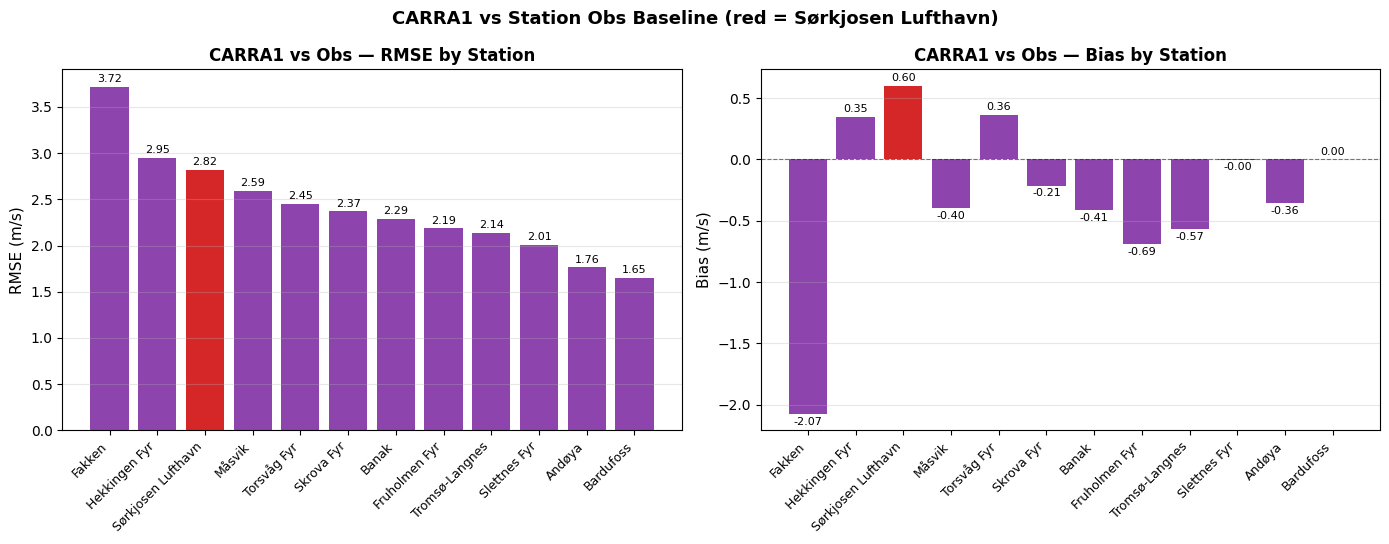

In [9]:
# Bar chart: CARRA1 vs Obs RMSE/Bias by station, Sørkjosen Lufthavn highlighted
order = metrics_carra_vs_obs_station.sort_values('RMSE', ascending=False)['station'].tolist()
labels = [STATIONS_BY_ID[s]['name'] for s in order]
is_sorkjosen = [s == 'SN91740' for s in order]
colors = ['#d62728' if flag else '#8E44AD' for flag in is_sorkjosen]

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
m = metrics_carra_vs_obs_station.set_index('station')

bars = ax_rmse.bar(range(len(order)), [m.loc[s, 'RMSE'] for s in order], color=colors)
ax_rmse.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax_rmse.set_xticks(range(len(order))); ax_rmse.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax_rmse.set_ylabel('RMSE (m/s)', fontsize=11)
ax_rmse.set_title('CARRA1 vs Obs — RMSE by Station', fontsize=12, fontweight='bold')
ax_rmse.grid(axis='y', alpha=0.3)

bars = ax_bias.bar(range(len(order)), [m.loc[s, 'Bias'] for s in order], color=colors)
ax_bias.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax_bias.set_xticks(range(len(order))); ax_bias.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax_bias.set_ylabel('Bias (m/s)', fontsize=11)
ax_bias.set_title('CARRA1 vs Obs — Bias by Station', fontsize=12, fontweight='bold')
ax_bias.grid(axis='y', alpha=0.3)

fig.suptitle('CARRA1 vs Station Obs Baseline (red = Sørkjosen Lufthavn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'carra_vs_obs_station_bar.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'carra_vs_obs_station_bar.pdf', bbox_inches='tight')
plt.show()


## 4. FCN3 / GraphCast / HRES vs CARRA1 — metrics & figures

Same `compute_group_metrics` framework already used for the vs-ERA5 and vs-Obs comparisons
elsewhere in this project, just with `ref_col='carra'` instead of `'era5'`/`'obs'`.


In [10]:
metrics_vs_carra_station = compute_group_metrics(master_df, 'forecast', 'carra', ['model', 'station'])
print('=== FCN3 / GraphCast / HRES vs CARRA1, by station (mean over lead time and years) ===')
display(metrics_vs_carra_station.assign(station=lambda d: d['station'].map(lambda s: STATIONS_BY_ID[s]['name']))
        .round(3))


=== FCN3 / GraphCast / HRES vs CARRA1, by station (mean over lead time and years) ===


,model,station,N,RMSE,MAE,Bias,nRMSE,nBias,Corr
0,FCN3,Skrova Fyr,30669.0,2.109,1.599,-0.436,34.100,-7.051,0.793
1,FCN3,Andøya,30669.0,2.202,1.689,0.599,38.382,10.434,0.773
2,FCN3,Hekkingen Fyr,30669.0,2.739,2.132,-1.279,41.394,-19.331,0.710
3,FCN3,Bardufoss,30669.0,1.533,1.073,-0.225,67.110,-9.849,0.597
4,FCN3,Tromsø-Langnes,30669.0,2.351,1.698,-1.237,60.958,-32.074,0.621
5,FCN3,Måsvik,30669.0,2.087,1.572,-0.122,38.775,-2.259,0.774
6,FCN3,Fakken,30669.0,2.471,1.921,-0.440,42.491,-7.571,0.638
7,FCN3,Torsvåg Fyr,30669.0,2.214,1.690,0.654,35.928,10.608,0.801
8,FCN3,Sørkjosen Lufthavn,30669.0,3.449,2.480,-2.308,73.823,-49.409,0.674
9,FCN3,Fruholmen Fyr,30669.0,2.219,1.654,0.262,31.096,3.668,0.809


In [11]:
# 4.0 Overall summary: station-level average per model (each of the 12 stations weighted
# equally, not pooled samples), plus station-to-station std — same convention used for the
# vs-Obs / vs-ERA5 summary tables elsewhere in this project.
avg_metrics_vs_carra = (metrics_vs_carra_station.groupby('model')
                         .agg(N_total=('N', 'sum'),
                              avg_RMSE=('RMSE', 'mean'), avg_MAE=('MAE', 'mean'), avg_Bias=('Bias', 'mean'),
                              avg_nRMSE=('nRMSE', 'mean'), avg_nBias=('nBias', 'mean'), avg_Corr=('Corr', 'mean'))
                         .reset_index())
_std = (metrics_vs_carra_station.groupby('model')[['RMSE', 'nRMSE', 'Bias', 'nBias']].std()
        .rename(columns={'RMSE': 'RMSE_std_across_stations', 'nRMSE': 'nRMSE_std_across_stations',
                          'Bias': 'Bias_std_across_stations', 'nBias': 'nBias_std_across_stations'}))
avg_metrics_vs_carra = avg_metrics_vs_carra.merge(_std.reset_index(), on='model').sort_values('avg_RMSE')

print('=== FCN3 / GraphCast / HRES vs CARRA1 — overall (12-station average, each station weighted equally) ===')
display(avg_metrics_vs_carra.round(3))
print()
print('Ranked by RMSE (lower is better):')
for i, row in enumerate(avg_metrics_vs_carra.itertuples(), 1):
    print(f'  {i}. {row.model:10s}  RMSE={row.avg_RMSE:.3f}  (+/-{row.RMSE_std_across_stations:.3f} across stations)')


=== FCN3 / GraphCast / HRES vs CARRA1 — overall (12-station average, each station weighted equally) ===


,model,N_total,avg_RMSE,avg_MAE,avg_Bias,avg_nRMSE,avg_nBias,avg_Corr,RMSE_std_across_stations,nRMSE_std_across_stations,Bias_std_across_stations,nBias_std_across_stations
1,GraphCast,368028.0,2.270,1.706,-0.974,44.103,-18.312,0.771,0.524,14.677,0.762,15.276
2,HRES,368028.0,2.292,1.715,-0.930,44.586,-17.974,0.764,0.478,14.600,0.763,15.710
0,FCN3,368028.0,2.373,1.779,-0.571,46.110,-12.150,0.722,0.476,14.655,0.917,18.556



Ranked by RMSE (lower is better):
  1. GraphCast   RMSE=2.270  (+/-0.524 across stations)
  2. HRES        RMSE=2.292  (+/-0.478 across stations)
  3. FCN3        RMSE=2.373  (+/-0.476 across stations)


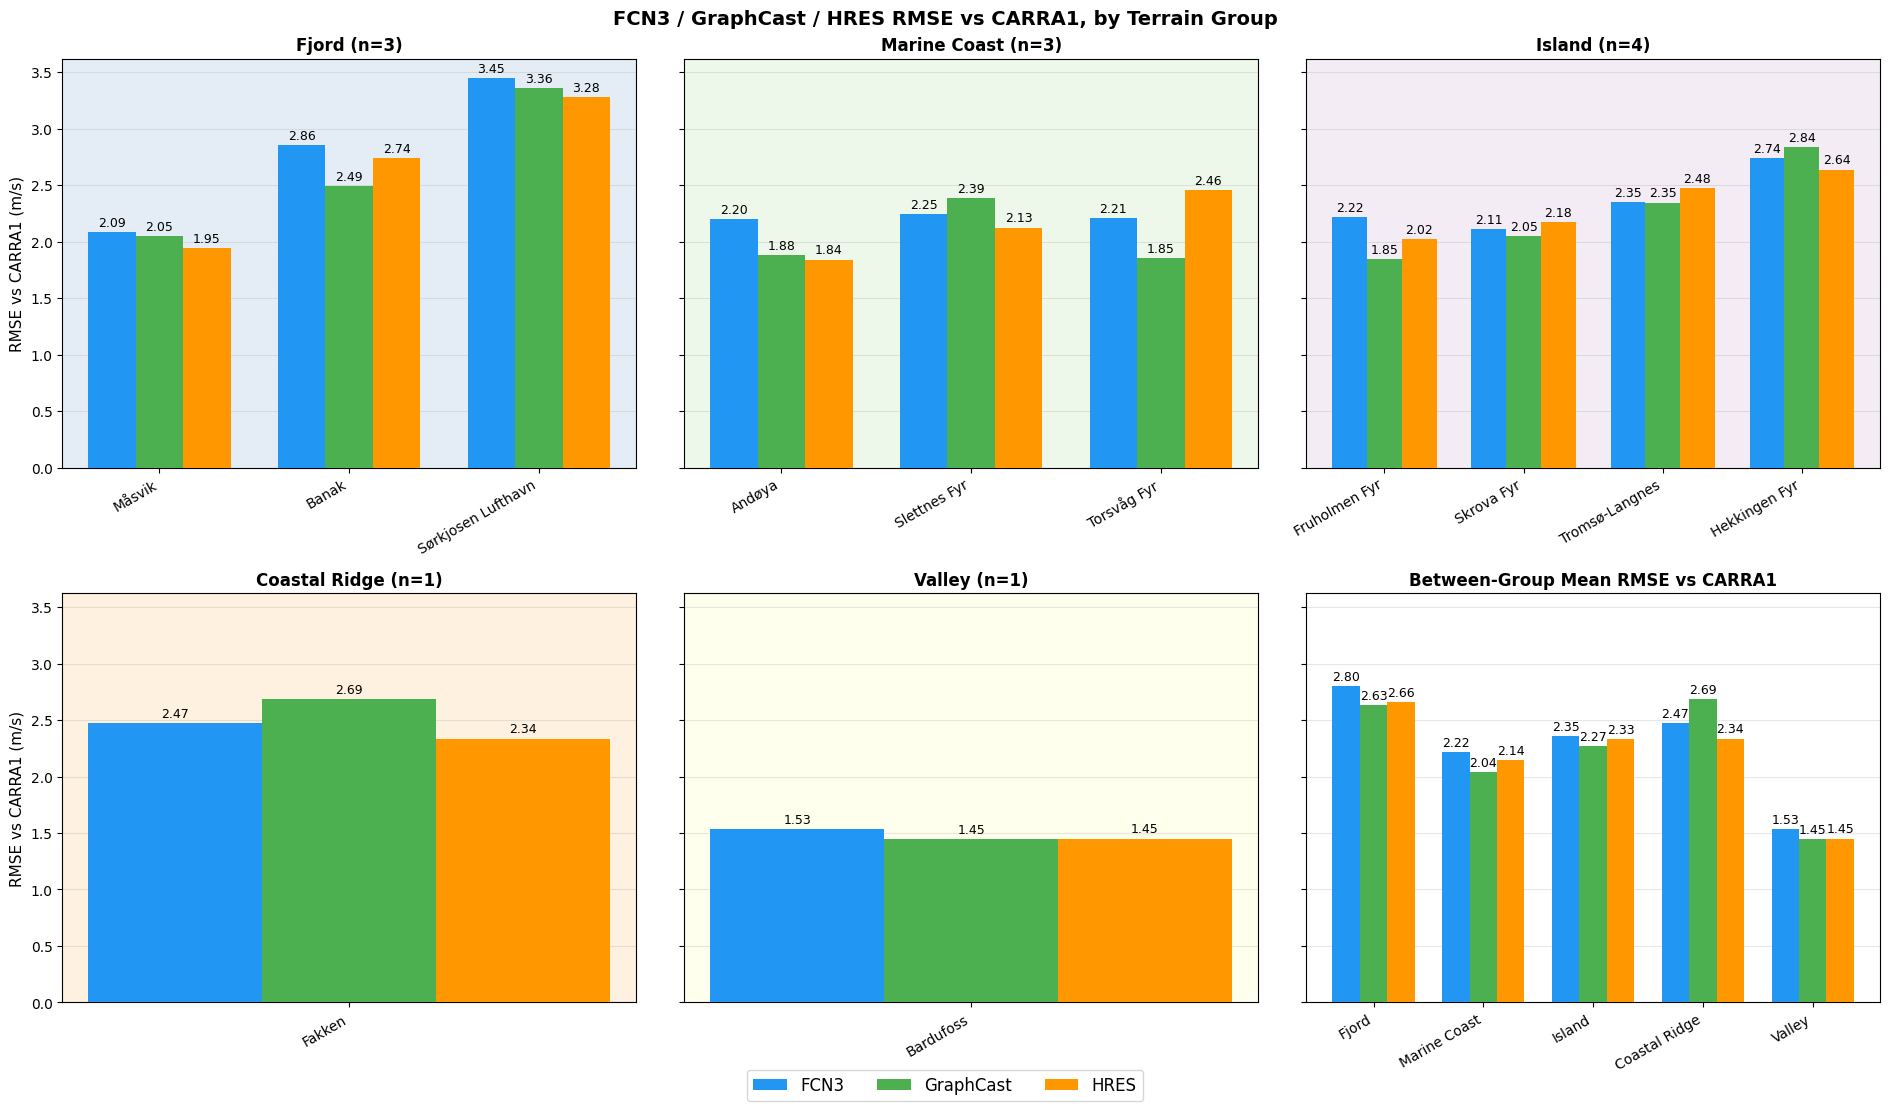

In [12]:
# 4.1 Station RMSE vs CARRA1, grouped by terrain category (mirrors Section 20.3 of the
# interpolate notebook, with CARRA in place of Obs as the reference)
station_model_mean_rmse_carra = metrics_vs_carra_station.groupby(['station', 'model'])['RMSE'].mean().reset_index()
hres_order_carra = (station_model_mean_rmse_carra[station_model_mean_rmse_carra['model'] == 'HRES']
                     .set_index('station')['RMSE'])

fig, axes = plt.subplots(2, 3, figsize=(19, 11), sharey=True)
axes = axes.flatten()

for ax, cat in zip(axes, TERRAIN_ORDER):
    stations_in_cat = sorted([s for s in STATION_ORDER if TERRAIN_CATEGORY[s] == cat],
                              key=lambda s: hres_order_carra.get(s, np.inf))
    ax.set_facecolor(TERRAIN_CLR[cat])
    ax.patch.set_alpha(0.35)
    x = np.arange(len(stations_in_cat)); w = 0.25
    for mi, model in enumerate(MODEL_ORDER):
        sub = station_model_mean_rmse_carra[station_model_mean_rmse_carra['model'] == model].set_index('station')
        vals = [sub['RMSE'].get(s, np.nan) for s in stations_in_cat]
        bars = ax.bar(x + (mi - 1) * w, vals, width=w, color=CLR[model], label=model, zorder=3)
        ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([STATIONS_BY_ID[s]['name'] for s in stations_in_cat], rotation=30, ha='right', fontsize=10)
    ax.set_title(f'{cat} (n={len(stations_in_cat)})', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y', zorder=0)

for ax in [axes[0], axes[3]]:
    ax.set_ylabel('RMSE vs CARRA1 (m/s)', fontsize=11)

ax_sum = axes[len(TERRAIN_ORDER)]
cat_x = np.arange(len(TERRAIN_ORDER)); w = 0.25
for mi, model in enumerate(MODEL_ORDER):
    vals = []
    for cat in TERRAIN_ORDER:
        stations_in_cat = [s for s in STATION_ORDER if TERRAIN_CATEGORY[s] == cat]
        sub = station_model_mean_rmse_carra[(station_model_mean_rmse_carra['model'] == model) &
                                             (station_model_mean_rmse_carra['station'].isin(stations_in_cat))]
        vals.append(sub['RMSE'].mean())
    bars = ax_sum.bar(cat_x + (mi - 1) * w, vals, width=w, color=CLR[model], label=model, zorder=3)
    ax_sum.bar_label(bars, fmt='%.2f', fontsize=9, padding=2, zorder=4)
ax_sum.set_xticks(cat_x)
ax_sum.set_xticklabels(TERRAIN_ORDER, rotation=30, ha='right', fontsize=10)
ax_sum.set_title('Between-Group Mean RMSE vs CARRA1', fontsize=12, fontweight='bold')
ax_sum.grid(alpha=0.3, axis='y', zorder=0)

for extra in axes[len(TERRAIN_ORDER) + 1:]:
    extra.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MODEL_ORDER), fontsize=12, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('FCN3 / GraphCast / HRES RMSE vs CARRA1, by Terrain Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rmse_vs_carra_by_terrain_group.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'rmse_vs_carra_by_terrain_group.pdf', bbox_inches='tight')
plt.show()


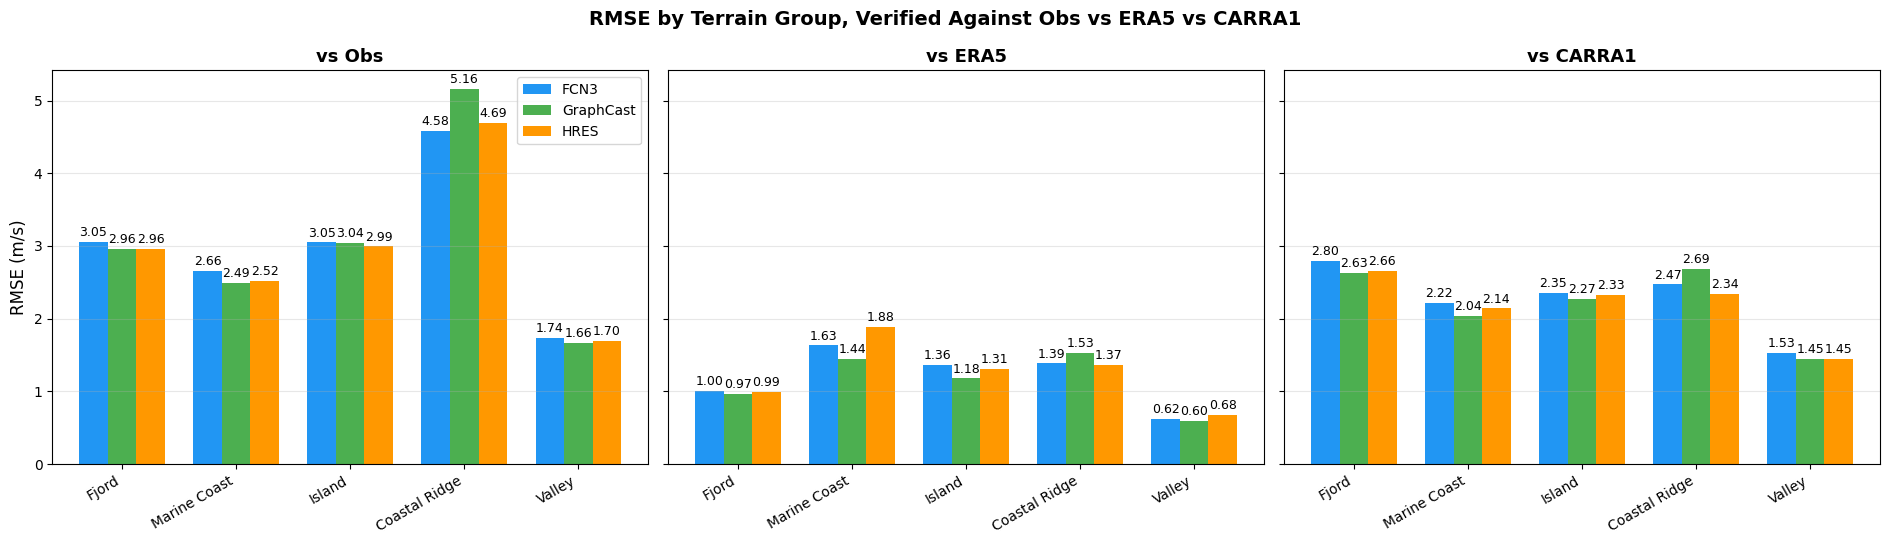

In [13]:
# 4.2 Side-by-side: RMSE vs Obs, vs ERA5, and vs CARRA1, by terrain group — is the model
# ranking / error pattern consistent across reference datasets, or does it change depending
# on what you verify against?
metrics_vs_obs_station  = compute_group_metrics(master_df, 'forecast', 'obs',  ['model', 'station'])
metrics_vs_era5_station = compute_group_metrics(master_df, 'forecast', 'era5', ['model', 'station'])

def _terrain_group_means(metrics_station_df):
    m = metrics_station_df.groupby(['station', 'model'])['RMSE'].mean().reset_index()
    rows = []
    for cat in TERRAIN_ORDER:
        stations_in_cat = [s for s in STATION_ORDER if TERRAIN_CATEGORY[s] == cat]
        for model in MODEL_ORDER:
            sub = m[(m['model'] == model) & (m['station'].isin(stations_in_cat))]
            rows.append({'terrain': cat, 'model': model, 'RMSE': sub['RMSE'].mean()})
    return pd.DataFrame(rows)

_ref_panels = [('Obs', metrics_vs_obs_station), ('ERA5', metrics_vs_era5_station),
               ('CARRA1', metrics_vs_carra_station)]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharey=True)
for ax, (ref_name, ref_metrics) in zip(axes, _ref_panels):
    g = _terrain_group_means(ref_metrics)
    x = np.arange(len(TERRAIN_ORDER)); w = 0.25
    for mi, model in enumerate(MODEL_ORDER):
        sub = g[g['model'] == model].set_index('terrain').reindex(TERRAIN_ORDER)
        bars = ax.bar(x + (mi - 1) * w, sub['RMSE'], width=w, color=CLR[model], label=model)
        ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(TERRAIN_ORDER, rotation=30, ha='right', fontsize=10)
    ax.set_title(f'vs {ref_name}', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('RMSE (m/s)', fontsize=12)
axes[0].legend(fontsize=10)

fig.suptitle('RMSE by Terrain Group, Verified Against Obs vs ERA5 vs CARRA1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rmse_by_terrain_group_ref_comparison.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'rmse_by_terrain_group_ref_comparison.pdf', bbox_inches='tight')
plt.show()


## 5. CARRA1 as a Fourth Method — Combined Ranking vs Station Obs

Sections 3.5-4 used CARRA1 as a *reference* (scoring FCN3/GraphCast/HRES against it, and
separately checking CARRA1's own quality against Obs). Here CARRA1 is instead treated as a
**peer method**, on the same footing as FCN3/GraphCast/HRES: all four are scored directly
against station Obs with the same `compute_group_metrics` function, and ranked together in
one table.

This reuses metrics already computed above rather than recomputing anything:
`metrics_vs_obs_station` (FCN3/GraphCast/HRES vs Obs, from Section 4.2) and
`metrics_carra_vs_obs_station` (CARRA1 vs Obs, from Section 3.5).


In [14]:
# 5.0 Combine FCN3/GraphCast/HRES-vs-Obs (Section 4.2) with CARRA1-vs-Obs (Section 3.5)
# into one table with a common 'model' column, so all four methods can be compared like-for-like.
ALL_METHODS_ORDER = MODEL_ORDER + ['CARRA1']

carra_component = metrics_carra_vs_obs_station.drop(columns='station_name').assign(model='CARRA1')
all_methods_vs_obs_station = pd.concat([metrics_vs_obs_station, carra_component], ignore_index=True)
all_methods_vs_obs_station = all_methods_vs_obs_station[
    ['model', 'station', 'N', 'RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']]

print('=== FCN3 / GraphCast / HRES / CARRA1 vs Station Obs, by station ===')
display(all_methods_vs_obs_station
        .assign(station=lambda d: d['station'].map(lambda s: STATIONS_BY_ID[s]['name']))
        .round(3))


=== FCN3 / GraphCast / HRES / CARRA1 vs Station Obs, by station ===


,model,station,N,RMSE,MAE,Bias,nRMSE,nBias,Corr
0,FCN3,Skrova Fyr,30573.0,2.757,2.143,-0.653,43.080,-10.208,0.674
1,FCN3,Andøya,30579.0,2.351,1.806,0.243,38.603,3.984,0.736
2,FCN3,Hekkingen Fyr,30573.0,3.572,2.858,-0.927,57.022,-14.801,0.528
3,FCN3,Bardufoss,30501.0,1.736,1.344,-0.226,75.912,-9.882,0.540
4,FCN3,Tromsø-Langnes,30579.0,3.033,2.314,-1.804,68.546,-40.769,0.604
5,FCN3,Måsvik,30537.0,2.831,2.165,-0.521,48.952,-9.000,0.675
6,FCN3,Fakken,30507.0,4.584,3.434,-2.512,58.141,-31.865,0.535
7,FCN3,Torsvåg Fyr,30579.0,2.988,2.317,1.017,51.542,17.542,0.696
8,FCN3,Sørkjosen Lufthavn,30447.0,2.978,2.180,-1.717,72.947,-42.065,0.610
9,FCN3,Fruholmen Fyr,30555.0,2.836,2.157,-0.426,36.267,-5.446,0.770


In [15]:
# 5.1 Overall summary: station-level average per method (each of the 12 stations weighted
# equally, not pooled samples) — same convention as Sections 3.5 and 4.0 — now covering all
# four methods, giving the new combined ranking vs Station Obs.
avg_metrics_vs_obs_all = (all_methods_vs_obs_station.groupby('model')
                           .agg(N_total=('N', 'sum'),
                                avg_RMSE=('RMSE', 'mean'), avg_MAE=('MAE', 'mean'), avg_Bias=('Bias', 'mean'),
                                avg_nRMSE=('nRMSE', 'mean'), avg_nBias=('nBias', 'mean'), avg_Corr=('Corr', 'mean'))
                           .reset_index())
_std_all = (all_methods_vs_obs_station.groupby('model')[['RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr']].std()
            .rename(columns={'RMSE': 'RMSE_std_across_stations', 'nRMSE': 'nRMSE_std_across_stations',
                              'Bias': 'Bias_std_across_stations', 'nBias': 'nBias_std_across_stations',
                              'Corr': 'Corr_std_across_stations'}))
avg_metrics_vs_obs_all = avg_metrics_vs_obs_all.merge(_std_all.reset_index(), on='model').sort_values('avg_RMSE')

print('=== FCN3 / GraphCast / HRES / CARRA1 vs Station Obs — overall (12-station average, each station weighted equally) ===')
display(avg_metrics_vs_obs_all.round(3))
print()
print('Combined ranking vs Station Obs (lower RMSE is better):')
for i, row in enumerate(avg_metrics_vs_obs_all.itertuples(), 1):
    print(f'  {i}. {row.model:10s}  RMSE={row.avg_RMSE:.3f}  (+/-{row.RMSE_std_across_stations:.3f} across stations)')


=== FCN3 / GraphCast / HRES / CARRA1 vs Station Obs — overall (12-station average, each station weighted equally) ===


,model,N_total,avg_RMSE,avg_MAE,avg_Bias,avg_nRMSE,avg_nBias,avg_Corr,RMSE_std_across_stations,nRMSE_std_across_stations,Bias_std_across_stations,nBias_std_across_stations,Corr_std_across_stations
0,CARRA1,121955.0,2.412,1.818,-0.284,44.665,-3.778,0.755,0.566,14.200,0.691,10.461,0.085
3,HRES,366585.0,2.899,2.215,-1.214,52.981,-21.522,0.686,0.741,14.608,0.835,15.018,0.084
2,GraphCast,366585.0,2.943,2.262,-1.258,53.362,-21.652,0.682,0.850,14.264,0.971,15.883,0.093
1,FCN3,366585.0,2.972,2.277,-0.854,54.235,-15.867,0.649,0.688,13.797,1.027,18.875,0.085



Combined ranking vs Station Obs (lower RMSE is better):
  1. CARRA1      RMSE=2.412  (+/-0.566 across stations)
  2. HRES        RMSE=2.899  (+/-0.741 across stations)
  3. GraphCast   RMSE=2.943  (+/-0.850 across stations)
  4. FCN3        RMSE=2.972  (+/-0.688 across stations)


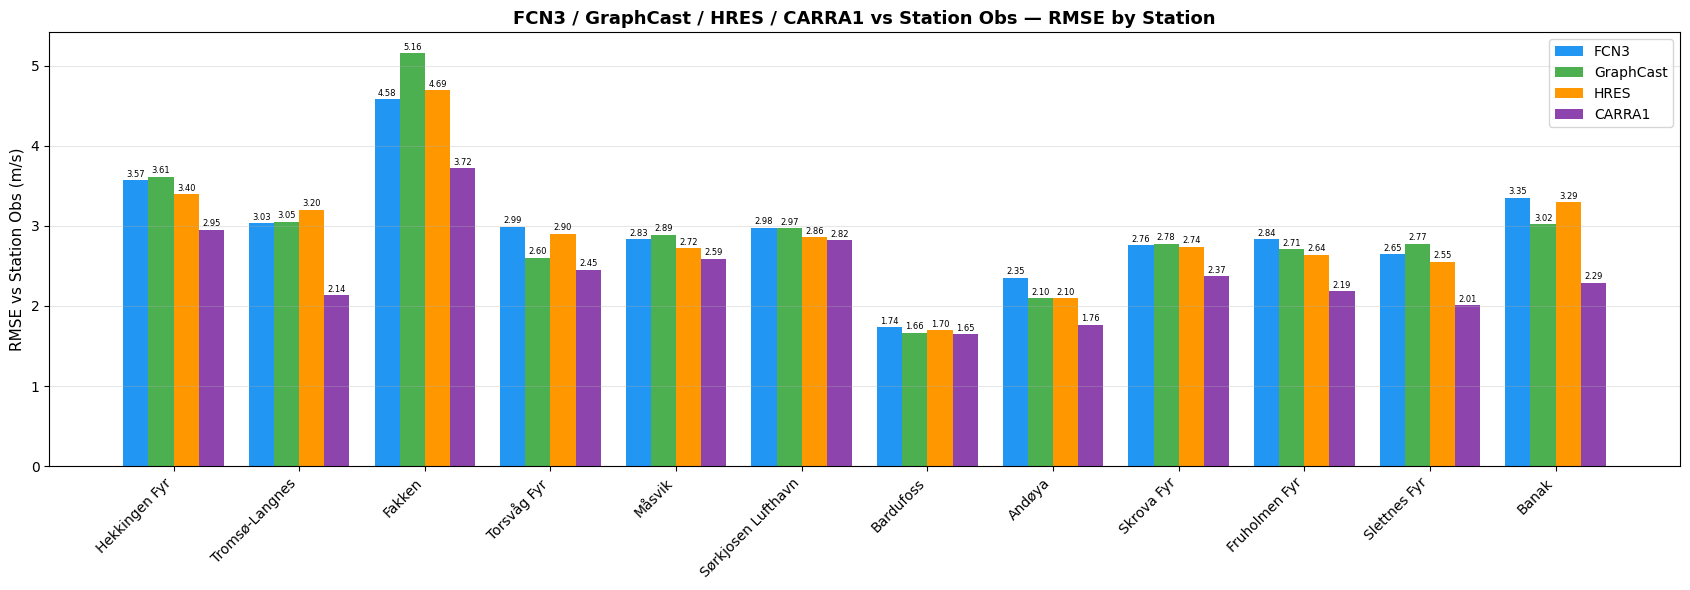

In [16]:
# 5.2 Grouped bar chart: RMSE vs Station Obs, all four methods, by station
METHOD_CLR = {**CLR, 'CARRA1': CLR['CARRA']}

order = STATION_ORDER
labels = [STATIONS_BY_ID[s]['name'] for s in order]
m = all_methods_vs_obs_station.set_index(['model', 'station'])
x = np.arange(len(order)); w = 0.2

fig, ax = plt.subplots(figsize=(17, 6))
for mi, method in enumerate(ALL_METHODS_ORDER):
    vals = [m.loc[(method, s), 'RMSE'] if (method, s) in m.index else np.nan for s in order]
    bars = ax.bar(x + (mi - 1.5) * w, vals, width=w, color=METHOD_CLR[method], label=method)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('RMSE vs Station Obs (m/s)', fontsize=11)
ax.set_title('FCN3 / GraphCast / HRES / CARRA1 vs Station Obs — RMSE by Station', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'all_methods_vs_obs_station_bar.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'all_methods_vs_obs_station_bar.pdf', bbox_inches='tight')
plt.show()


### 5.3 Metrics used & how to read the combined ranking

**Metrics** (all from the shared `compute_group_metrics(df, pred_col, ref_col, group_cols)`
helper in Section 3 — the same function behind every Obs/ERA5/CARRA1 comparison in this
notebook, here called with `pred_col` = each method's wind speed and `ref_col='obs'`):

| Metric | Definition | Unit |
|---|---|---|
| **N** | Sample count in the group | — |
| **RMSE** | Root-mean-squared error, `sqrt(mean((pred - obs)^2))` — penalizes large errors more than MAE | m/s |
| **MAE** | Mean absolute error, `mean(\|pred - obs\|)` | m/s |
| **Bias** | Mean signed error, `mean(pred - obs)` — positive = over-forecast, negative = under-forecast | m/s |
| **nRMSE** | RMSE normalized by mean Obs wind speed in the group | % |
| **nBias** | Bias normalized by mean Obs wind speed in the group | % |
| **Corr** | Pearson correlation between predicted and observed wind speed | — |

**Overall / ranking convention**: `avg_metrics_vs_obs_all` (5.1) averages the 12 per-station
values with every station weighted equally — not pooled across all samples, which would let
stations with more valid pairs dominate. This is the same convention already used for the
CARRA1-vs-Obs summary (Section 3.5) and the models-vs-CARRA1 summary (Section 4.0), so the new
4-way ranking is directly comparable to those. The printed "Combined ranking vs Station Obs"
list in 5.1 orders all four methods by `avg_RMSE`, lowest (best) first.

Note CARRA1 is a 3-hourly reanalysis *interpolated to each forecast valid time*, not a
lead-time-dependent forecast — its RMSE vs Obs has no lead-time dependence, unlike FCN3/
GraphCast/HRES. A method with lower overall RMSE than CARRA1 is beating an analysis-quality
product, not just another forecast.
